In [12]:
import tensorflow as tf

x = tf.Variable(5.0)
with tf.GradientTape() as tape:
    y = x ** 2
grad = tape.gradient(y, x)
print(grad.numpy())  # Output: 10.0

10.0


In [13]:
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
from PIL import Image

train_dir = "E:\\6CS012\\Week 4 - Multi Layer Neural Network\\DevanagariHandwrittenDigitDataset\\Train\\"
test_dir  = "E:\\6CS012\\Week 4 - Multi Layer Neural Network\\DevanagariHandwrittenDigitDataset\\Test\\"
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")        # grayscale
            img = img.resize((img_width, img_height))       # resize to 28x28
            img = np.array(img) / 255.0                     # normalize to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Reshape for Keras: (num_samples, 28, 28, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1,  img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set:  {x_test.shape},  Labels: {y_test.shape}")

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:  (3000, 28, 28, 1),  Labels: (3000, 10)


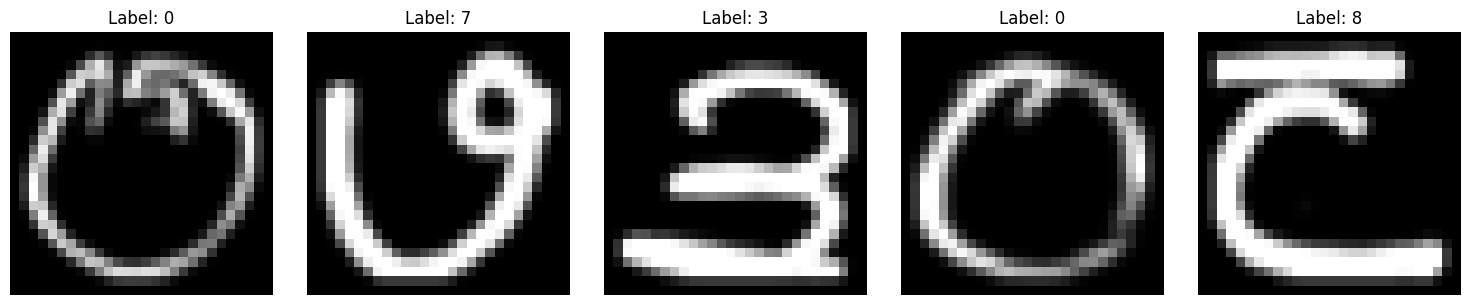

In [14]:

import matplotlib.pyplot as plt
# lets randomly sample 5 images from the training set
n = 5
indices = np.random.choice(len(x_train), n, replace=False)

fig, axes = plt.subplots(1, n, figsize=(15, 3))

for ax, idx in zip(axes, indices):
    ax.imshow(x_train[idx].reshape(img_height, img_width), cmap='gray')
    ax.set_title(f"Label: {np.argmax(y_train[idx])}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf
from tensorflow import keras

num_classes  = 10
input_shape  = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),                          # 28x28x1 → 784
    keras.layers.Dense(64,  activation="sigmoid"),   # hidden layer 1
    keras.layers.Dense(128, activation="sigmoid"),   # hidden layer 2
    keras.layers.Dense(256, activation="sigmoid"),   # hidden layer 3
    keras.layers.Dense(num_classes, activation="softmax"),  # output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",                    # adaptive learning rate optimizer
    loss="categorical_crossentropy",     # because labels are one-hot encoded
    metrics=["accuracy"]
)

In [22]:
batch_size = 128
epochs     = 20        

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,     # 20% of training data used for validation
    callbacks=callbacks,
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9400 - loss: 0.2246 - val_accuracy: 0.1522 - val_loss: 7.0105
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9648 - loss: 0.1253 - val_accuracy: 0.1780 - val_loss: 7.2525
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9721 - loss: 0.1007 - val_accuracy: 0.1976 - val_loss: 7.2677
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9781 - loss: 0.0815 - val_accuracy: 0.2404 - val_loss: 7.3475
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9810 - loss: 0.0693 - val_accuracy: 0.2216 - val_loss: 7.3558


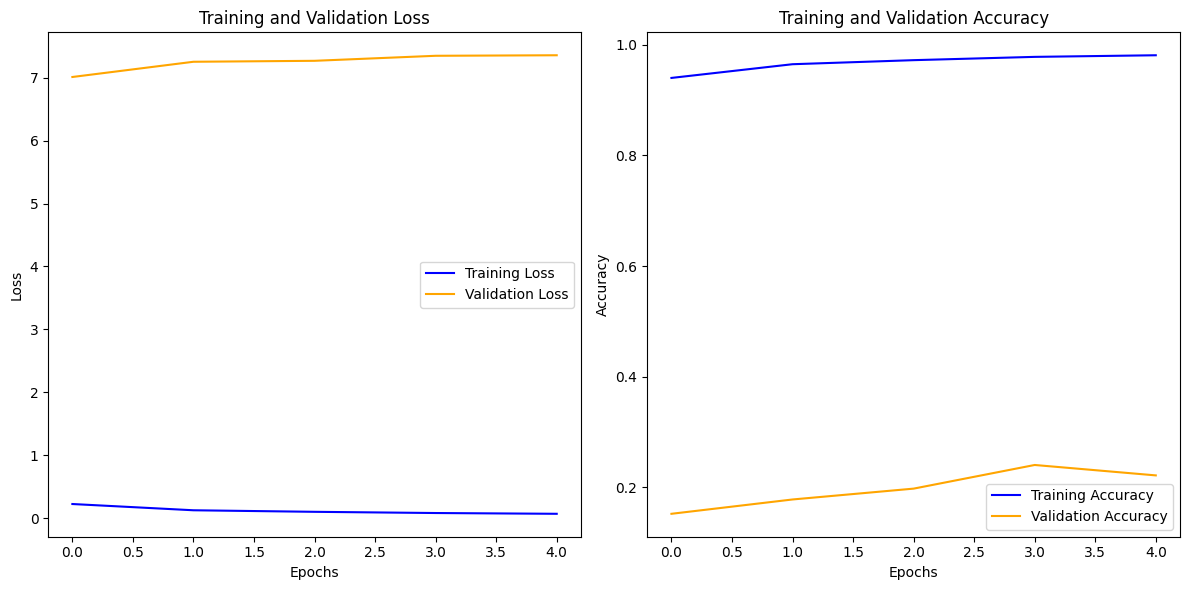

In [23]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss',   color='blue')
plt.plot(val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy',   color='blue')
plt.plot(val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 1ms/step - accuracy: 0.7643 - loss: 2.2217
Test accuracy: 0.7643


In [24]:
predictions = model.predict(x_test)

# Convert probability distributions to class labels
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
Predicted label for first image: 0
True label for first image:      0


In [25]:
# Save
model.save('devnagari_fcn_model.h5')

# Load and re-evaluate
import tensorflow as tf
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')

loss, acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded model test accuracy: {acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.8570 - loss: 1.1953
Loaded model test accuracy: 0.8570
